In [1]:
import pandas as pd

orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')

print("Datasets loaded successfully")

Datasets loaded successfully


In [2]:
print(orders.shape)
print(orders.columns.tolist())
orders.head()

(99441, 8)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [4]:
total_orders = len(orders)
delivered = orders[orders['order_status'] == 'delivered'].shape[0]
cancelled = orders[orders['order_status'] == 'canceled'].shape[0]

print(f"Total Orders: {total_orders}")
print(f"Delivered: {delivered} ({delivered/total_orders*100:.1f}%)")
print(f"Cancelled: {cancelled} ({cancelled/total_orders*100:.1f}%)")

Total Orders: 99441
Delivered: 96478 (97.0%)
Cancelled: 625 (0.6%)


In [5]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['delivery_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.days
delivered_orders['delay_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days

print(f"Average delivery time: {delivered_orders['delivery_days'].mean():.1f} days")
print(f"Average delay (negative = early): {delivered_orders['delay_days'].mean():.1f} days")

Average delivery time: 12.1 days
Average delay (negative = early): -11.9 days


In [6]:
avg_order_value = payments.groupby('order_id')['payment_value'].sum().reset_index()
avg_order_value.columns = ['order_id', 'total_payment']

print(f"Average order value: R$ {avg_order_value['total_payment'].mean():.2f}")
print(f"Median order value: R$ {avg_order_value['total_payment'].median():.2f}")
print(f"Max order value: R$ {avg_order_value['total_payment'].max():.2f}")

Average order value: R$ 160.99
Median order value: R$ 105.29
Max order value: R$ 13664.08


In [7]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [8]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [9]:
print(f"Average review score: {reviews['review_score'].mean():.2f} / 5")
print(f"5-star rate: {(reviews['review_score'] == 5).sum() / len(reviews) * 100:.1f}%")
print(f"1-star rate: {(reviews['review_score'] == 1).sum() / len(reviews) * 100:.1f}%")

Average review score: 4.09 / 5
5-star rate: 57.8%
1-star rate: 11.5%


In [10]:
funnel_stages = {
    'Created': total_orders,
    'Approved': orders[orders['order_status'].isin(['approved', 'processing', 'invoiced', 'shipped', 'delivered'])].shape[0],
    'Shipped': orders[orders['order_status'].isin(['shipped', 'delivered'])].shape[0],
    'Delivered': delivered
}

for stage, count in funnel_stages.items():
    print(f"{stage}: {count} ({count/total_orders*100:.1f}%)")

Created: 99441 (100.0%)
Approved: 98202 (98.8%)
Shipped: 97585 (98.1%)
Delivered: 96478 (97.0%)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


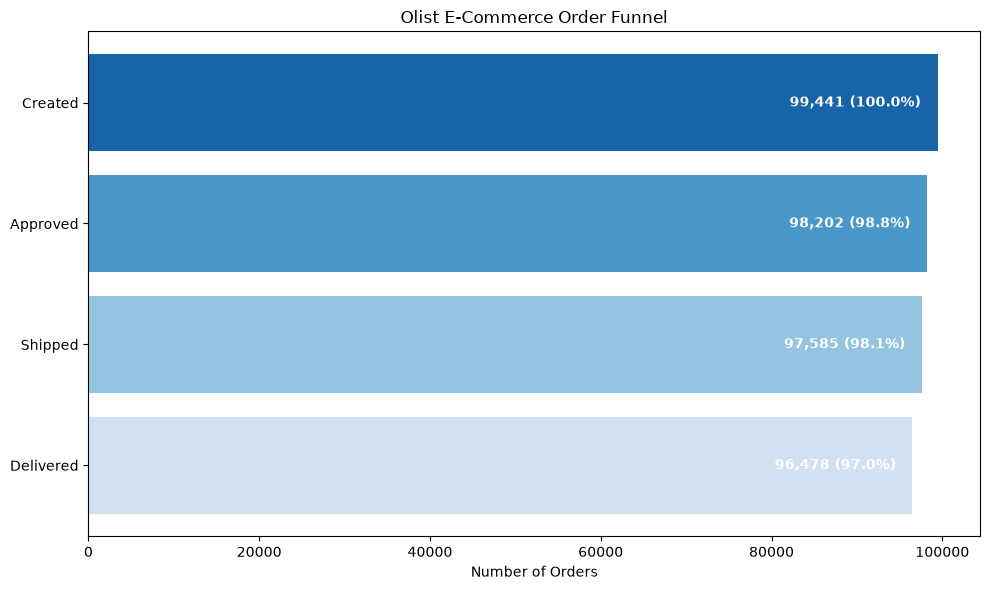

In [12]:
stages = list(funnel_stages.keys())
counts = list(funnel_stages.values())

plt.figure(figsize=(10,6))
bars = plt.barh(stages, counts, color=sns.color_palette('Blues_r', len(stages)))
plt.xlabel('Number of Orders')
plt.title('Olist E-Commerce Order Funnel')
plt.gca().invert_yaxis()

for bar, count in zip(bars, counts):
    plt.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height()/2,
             f'{count:,} ({count/total_orders*100:.1f}%)',
             va='center', ha='right', color='white', fontweight='bold')
    
plt.tight_layout()
plt.savefig('../funnel_chart.png', dpi=150)
plt.show()

In [13]:
low_reviews = reviews[reviews['review_score'] == 1].copy()
high_reviews = reviews[reviews['review_score'] == 5].copy()

print(f"1-star reviews: {len(low_reviews)}")
print(f"5-star reviews: {len(high_reviews)}")

low_merged = low_reviews.merge(delivered_orders[['order_id', 'delivery_days', 'delay_days']], on='order_id', how='left')
high_merged = high_reviews.merge(delivered_orders[['order_id', 'delivery_days', 'delay_days']], on='order_id', how='left')

print(f"\n1-star avg delivery days: {low_merged['delivery_days'].mean():.1f}")
print(f"5-star avg delivery days: {high_merged['delivery_days'].mean():.1f}")

1-star reviews: 11424
5-star reviews: 57328

1-star avg delivery days: 20.8
5-star avg delivery days: 10.2


In [14]:
products = pd.read_csv('../data/olist_products_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

product = products.merge(category_translation, on='product_category_name', how='left')
items_products = order_items.merge(product[['product_id', 'product_category_name_english']], on='product_id', how='left')

top_categories = items_products['product_category_name_english'].value_counts().head(10)

print(top_categories)

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


C:\Users\John Matthew\AppData\Local\Temp\ipykernel_11388\1130113974.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='Blues_r')


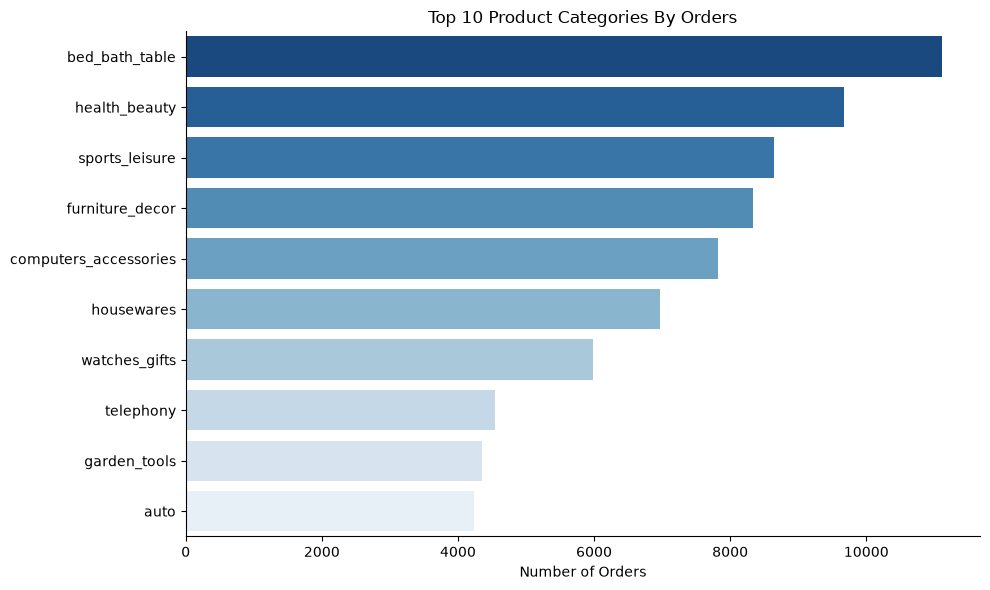

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='Blues_r')
plt.title('Top 10 Product Categories By Orders')
plt.xlabel('Number of Orders')
plt.ylabel('')
sns.despine()
plt.tight_layout()
plt.savefig('../top_categories.png', dpi=150)
plt.show()

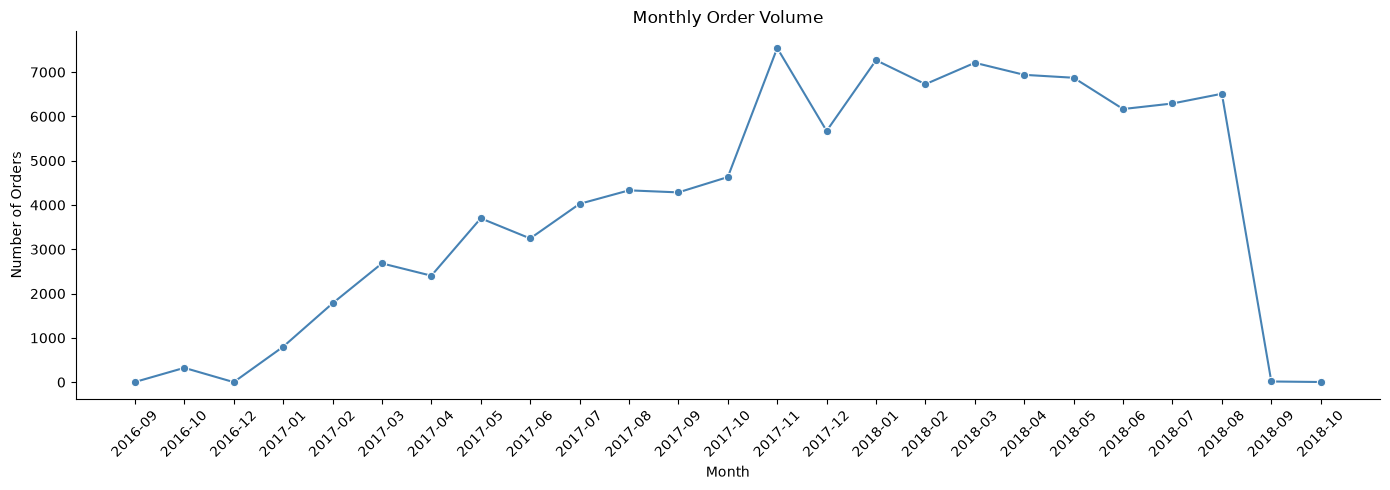

In [16]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('order_month').size().reset_index(name='order_count')
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

plt.figure(figsize=(14,5))
sns.lineplot(x='order_month', y='order_count', data=monthly_orders, marker='o', color='steelblue')
plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig('../monthly_trends.png', dpi=150)
plt.show()

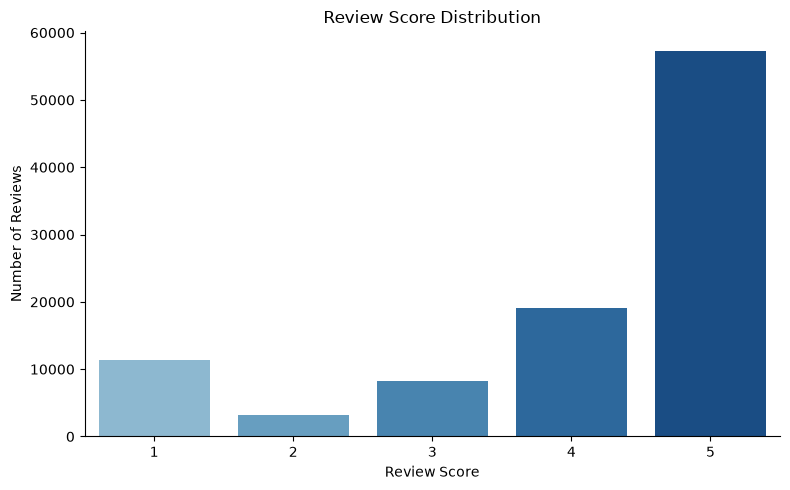

In [17]:
plt.figure(figsize=(8,5))
review_counts = reviews['review_score'].value_counts().sort_index()
sns.barplot(x=review_counts.index, y=review_counts.values, hue=review_counts.index, palette=sns.color_palette('Blues', 8)[3:], legend=False)
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
sns.despine()
plt.tight_layout()
plt.savefig('../review_distribution.png', dpi=150)
plt.show()

In [18]:
delivered_orders.to_csv('../data/delivered_orders_clean.csv', index=False)
monthly_orders.to_csv('../data/monthly_orders.csv', index=False)
avg_order_value.to_csv('../data/avg_order_value.csv', index=False)

print("Export done")

Export done


In [19]:
top_categories_df = items_products['product_category_name_english'].value_counts().reset_index()
top_categories_df.columns = ['category', 'order_count']
top_categories_df.to_csv('../data/top_categories.csv', index=False)

print("Export done")

Export done


In [20]:
# Clean category names for Power BI
top_categories_df['category'] = top_categories_df['category'].str.replace('_', ' ').str.title()
top_categories_df.to_csv('../data/top_categories.csv', index=False)
print("Done")

Done
